# День 6. Описательная статистика и проверка гипотез

**Курс:** ДПК «Практические навыки и опыт анализа данных с помощью Python»  
**Источник данных:** карьер «Восточный» (золотодобыча) — реальная производственная телеметрия и геомеханика.

> 💡 Заполняйте ячейки `# TODO`. Подсказки даны в комментариях. Не стесняйтесь спрашивать преподавателя.


## Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Базовые настройки
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

DATA_DIR =   # путь к папке с датасетами


## Задание 6.1. «Статистический паспорт литотипов»


In [ ]:
gold = ...



(5000, 18)


### Mean, median, std, quartiles по литотипам

In [ ]:
params = ['RATE_OF_PENETRATION', 'TORQUE', 'WEIGHT_ON_BIT', 'ROTATION_PER_MINUTE']
params = [p for p in params if p in gold.columns]

# TODO: groupby + agg со списком функций
stats = gold.groupby('')[params].agg(
    
    ).round(2)
stats


RATE_OF_PENETRATION                                                   TORQUE                            \
                                                              mean median     std   min    max <lambda_0> <lambda_1>   mean median   std   min    max   
Litology_Code                                                                                                                                           
carbonaceous quartz-mica calcium metasomatites              144.27   81.0  151.73  30.0  552.0       52.5      145.8  12.71  12.83  4.93  3.54  19.71   
carbonized_quartz-mica_hornfels_shists                      114.77   48.0  171.25   0.6  990.0       36.0      102.0  11.40  13.82  5.36  0.00  22.87   
fault_zone                                                   99.27   54.0  159.39  30.0  910.8       42.0       84.0  11.78  14.33  5.96  0.00  21.79   
mica-quartz_carbonate_massive_rocks                         129.45   60.0  184.82   4.2  996.0       42.0      114.0  12.80  14.87  5.23  0.00  23.42   
quartz-mica foliated schists                                134.97   66.0  175.57   6.0  997.8       54.0      120.0  12.53  15.02  5.27  0.00  23.51   

                                                                     WEIGHT_ON_BIT                                                      ROTATION_PER_MINUTE  \
                                               <lambda_0> <lambda_1>          mean  median     std    min     max <lambda_0> <lambda_1>                mean   
Litology_Code                                                                                                                                                 
carbonaceous quartz-mica calcium metasomatites       9.38      17.40        252.21  244.67  162.81  10.29  442.50     102.29     420.03              106.80   
carbonized_quartz-mica_hornfels_shists               7.48      15.29        240.59  306.36  162.81 -57.03  430.20      66.78     398.55               89.36   
fault_zone                                           7.16      15.89        266.48  387.74  163.91  -0.95  411.61      79.49     403.06               87.65   
mica-quartz_carbonate_massive_rocks                  8.85      16.45        282.54  383.71  162.03 -59.12  452.61     106.94     419.47               99.29   
quartz-mica foliated schists                         8.61      16.31        271.03  354.04  164.26 -55.70  451.91     106.09     420.56               96.27   

                                                                                             
                                               median    std min  max <lambda_0> <lambda_1>  
Litology_Code                                                                                
carbonaceous quartz-mica calcium metasomatites  109.0  11.94  59  115     108.75     112.25  
carbonized_quartz-mica_hornfels_shists          109.0  34.08   0  118      75.00     110.00  
fault_zone                                      108.0  35.00   0  115      68.00     109.00  
mica-quartz_carbonate_massive_rocks             109.0  20.86   0  122      97.00     110.00  
quartz-mica foliated schists                    109.0  25.51   0  123      94.00     110.00

### Коэффициент вариации CV = std / mean

In [ ]:
# TODO: посчитать CV для ROP по литотипам
cv_by_litho = ...
cv_by_litho.sort_values(ascending=False)


Litology_Code
fault_zone                                        1.606
carbonized_quartz-mica_hornfels_shists            1.492
mica-quartz_carbonate_massive_rocks               1.428
quartz-mica foliated schists                      1.301
carbonaceous quartz-mica calcium metasomatites    1.052
Name: RATE_OF_PENETRATION, dtype: float64

---
## Задание 6.2. «Категоризация скорости проходки»


In [ ]:
# TODO: pd.qcut на 4 категории
labels = ['медленная', 'ниже среднего', 'выше среднего', 'быстрая']
gold[] = ...
gold[].value_counts()


rop_category
медленная        1356
быстрая          1248
ниже среднего    1226
выше среднего    1170
Name: count, dtype: int64

In [ ]:
# Crosstab Litology_Code × rop_category, нормализованный по строкам
ct = ...
ct


rop_category,медленная,ниже среднего,выше среднего,быстрая
Litology_Code,,,,
carbonaceous quartz-mica calcium metasomatites,0.100,0.200,0.350,0.350
carbonized_quartz-mica_hornfels_shists,0.422,0.194,0.155,0.229
fault_zone,0.327,0.286,0.224,0.163
mica-quartz_carbonate_massive_rocks,0.267,0.238,0.234,0.261
quartz-mica foliated schists,0.090,0.314,0.330,0.266


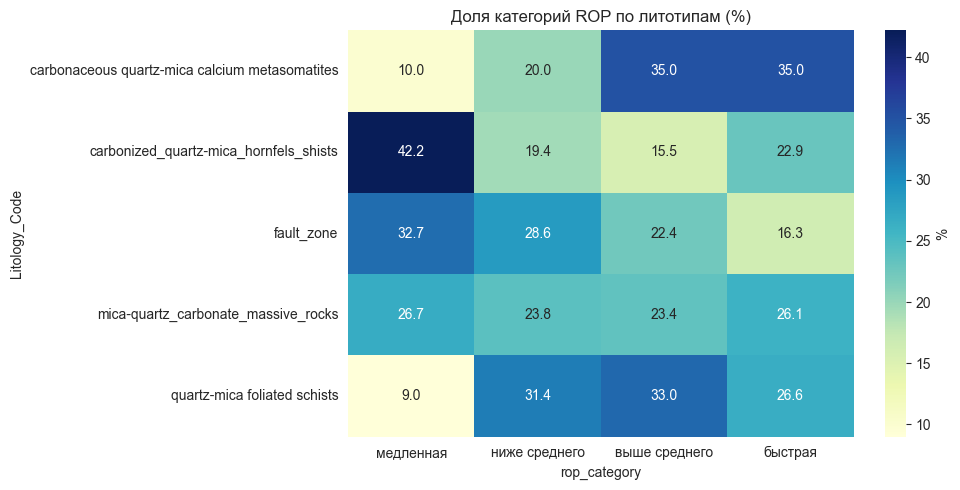

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
...
ax.set_title('Доля категорий ROP по литотипам (%)')
plt.tight_layout()
plt.show()


---
## Задание 6.3. «Сравнение двух паспортов бурения»

Проверка гипотезы: отличается ли средняя ROP между паспортами?

**H0:** средние одинаковы. **H1:** средние различаются.

In [ ]:
passports = gold['...'].unique()
print('Доступные паспорта:', passports)

p1, p2 = passports[0], passports[1]
sample1 =...
sample2 =...
print(f'{p1}: n = {len(sample1)}, mean = {sample1.mean():.2f}')
print(f'{p2}: n = {len(sample2)}, mean = {sample2.mean():.2f}')


Доступные паспорта: ['605-E230725_P_B_9.B' '630-E040625_P_B_4.A' '630-E030525_P_B_1.B']
605-E230725_P_B_9.B: n = 1505, mean = 122.71
630-E040625_P_B_4.A: n = 1984, mean = 114.39


### Шаг 1. Визуальная проверка нормальности (Q-Q plot + гистограмма)

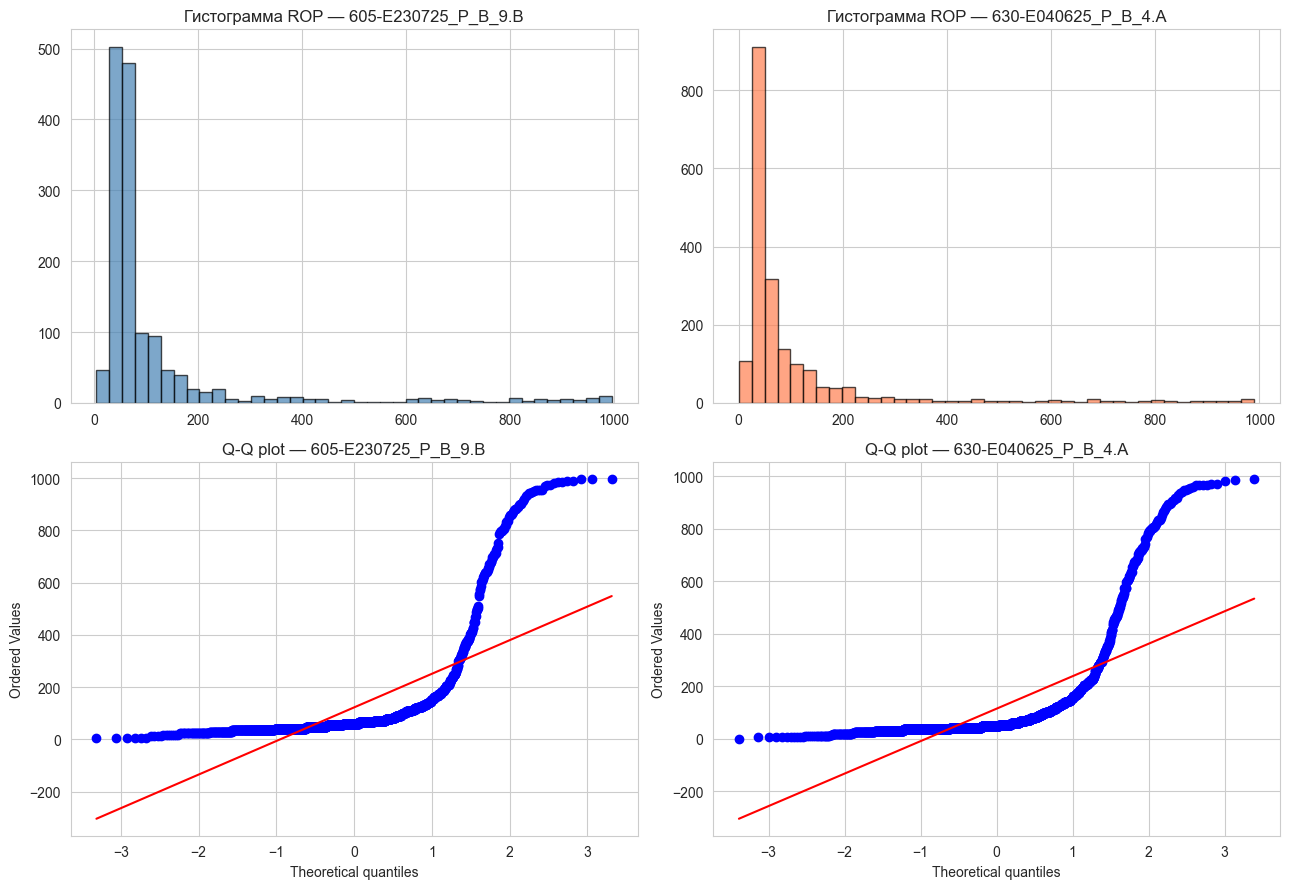

In [ ]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].set_title(f'Гистограмма ROP — {p1}')

axes[0,1].set_title(f'Гистограмма ROP — {p2}')

axes[1,0].set_title(f'Q-Q plot — {p1}')

axes[1,1].set_title(f'Q-Q plot — {p2}')
plt.tight_layout()
plt.show()


### Шаг 2. Выбор теста

Если распределения нормальные → t-test независимых выборок.  
Если нет → U-критерий Манна-Уитни (непараметрический аналог).

In [ ]:
# t-test
t_stat, t_p = ...
print(f't-test: t = {t_stat:.3f}, p = {t_p:.4g}')

# Mann-Whitney U
u_stat, u_p = ...
print(f'Mann-Whitney: U = {u_stat:.1f}, p = {u_p:.4g}')


t-test: t = 1.380, p = 0.1678
Mann-Whitney: U = 1695657.5, p = 5.258e-12


### Шаг 3. Вывод

Выберите α = 0.05 и сформулируйте вывод по правильной форме:

_«На основании ... теста (p = ...) на уровне значимости α = 0.05 (отвергаем / не можем отвергнуть) гипотезу о равенстве средних. Это означает, что средние ROP паспортов ... (статистически значимо различаются / нельзя считать различающимися)»_

**⚠ Важно:** p-value НЕ показывает вероятность того, что гипотеза верна. Это вероятность получить такие же или ещё более экстремальные данные ПРИ УСЛОВИИ, что H0 верна.